In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as sns

#loading the current file
df = pd.read_pickle('data_frame.pkl')

c:\Users\mstaw\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Creating 3 new columns
df['Day'] = df.InvoiceDate.dt.strftime('%a')
df['Month'] = df.InvoiceDate.dt.strftime('%b')
df['Year'] = df.InvoiceDate.dt.year
df['Hour'] = df.InvoiceDate.dt.hour
df.sample(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,StatusofOrder,Revenue,Day,Month,Year,Hour
305968,563728,22553,PLASTERS IN TIN SKULLS,1,2011-08-18 17:09:00,1.65,17045.0,United Kingdom,Endorsed,1.65,Thu,Aug,2011,17
507218,579170,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,2011-11-28 14:26:00,3.75,17811.0,United Kingdom,Endorsed,3.75,Mon,Nov,2011,14
213353,555537,22318,FIVE HEART HANGING DECORATION,1,2011-06-05 12:37:00,2.95,15453.0,United Kingdom,Endorsed,2.95,Sun,Jun,2011,12
178885,552244,22971,QUEENS GUARD COFFEE MUG,1,2011-05-06 19:39:00,2.55,12748.0,United Kingdom,Endorsed,2.55,Fri,May,2011,19
526980,580687,23583,LUNCH BAG PAISLEY PARK,20,2011-12-05 15:38:00,1.65,16379.0,United Kingdom,Endorsed,33.00,Mon,Dec,2011,15


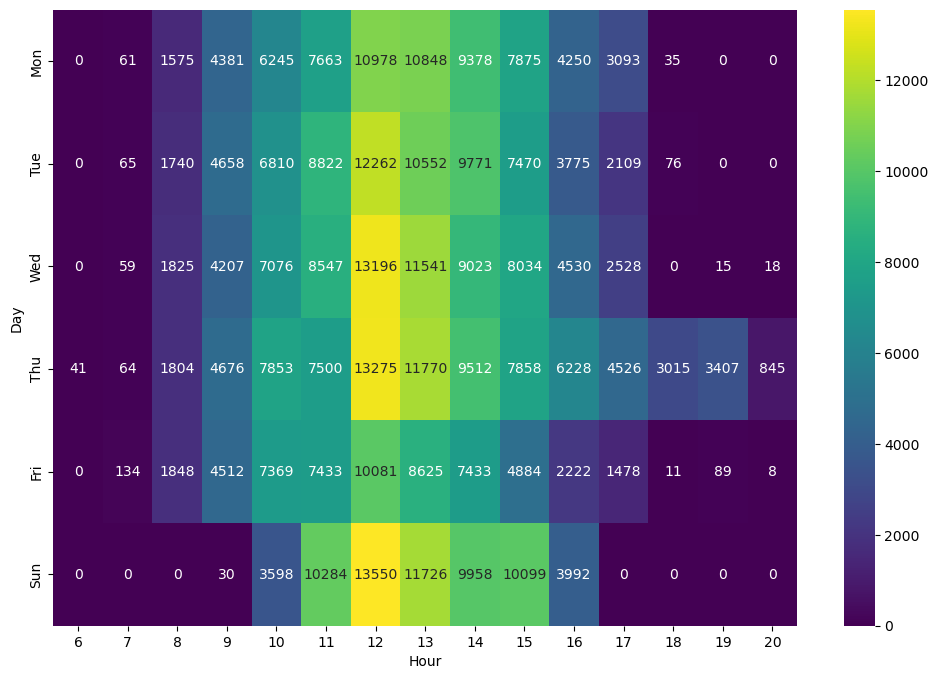

In [3]:
#What are tthe busiest hours in which days

pivot = df.pivot_table(
    values='InvoiceNo',
    index='Day',             
    columns='Hour', 
    aggfunc='count',
    fill_value=0               
)
rigth_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sun']
pivot = pivot.reindex(rigth_order)
#plot
plt.figure(figsize=(12, 8))
sns.heatmap(pivot, cmap = 'viridis',annot=True,fmt='.0f')
plt.show()


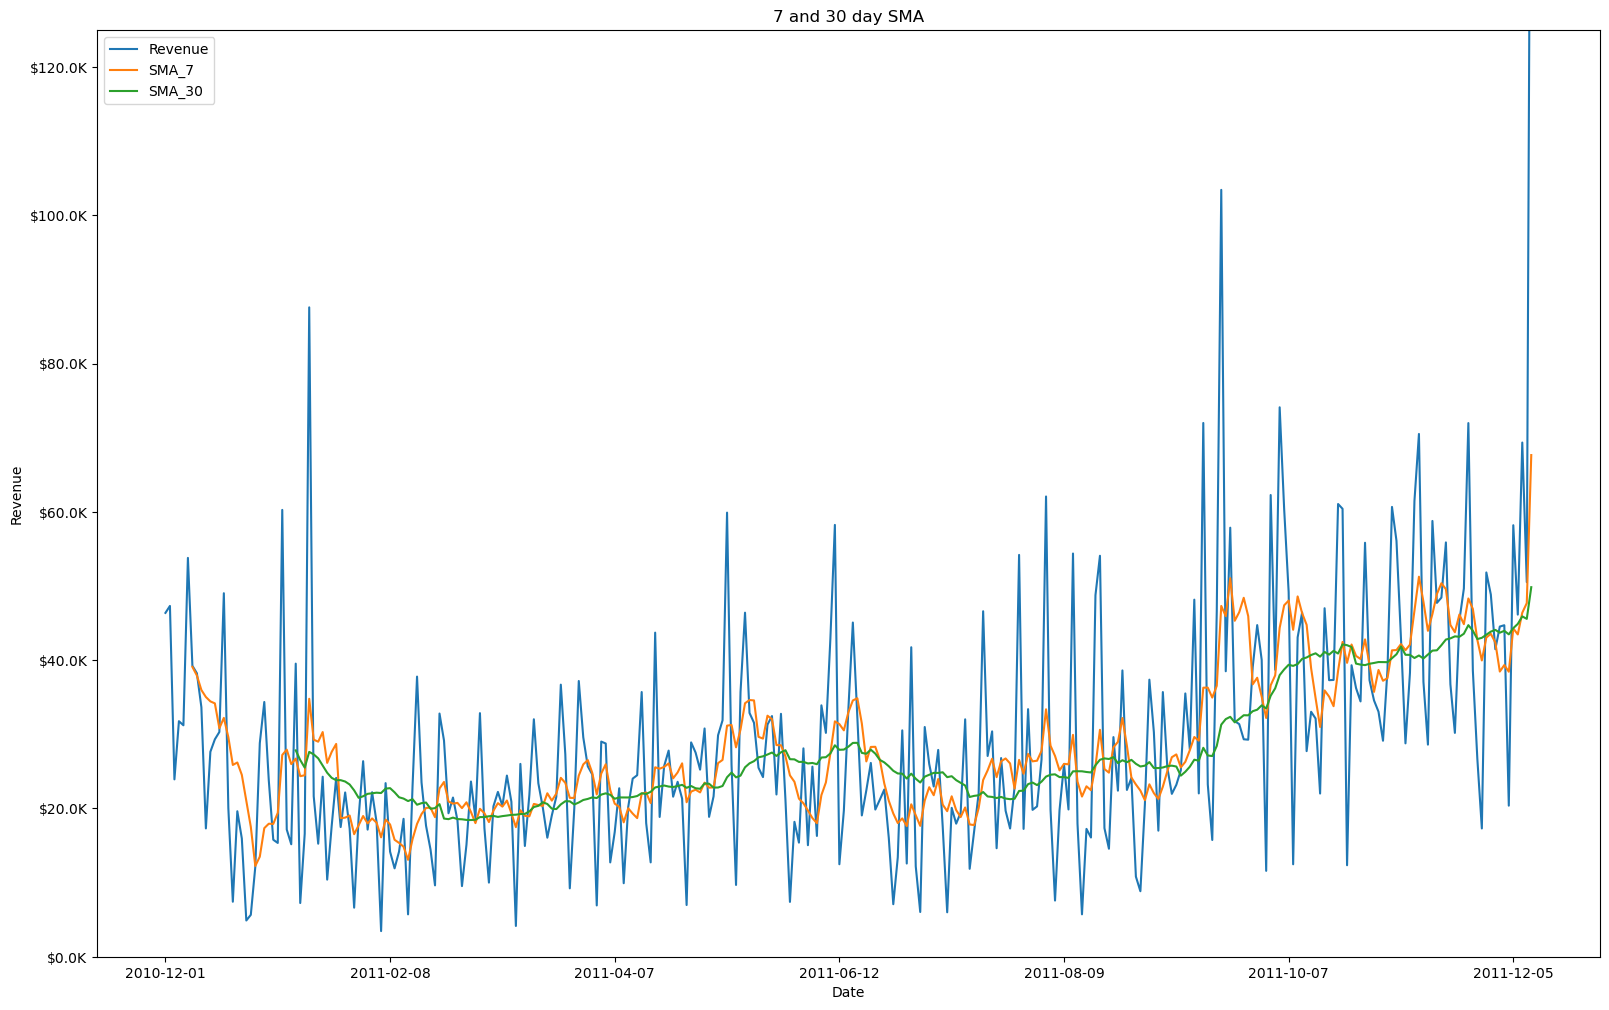

In [4]:
df['DateWithoutHour'] = df.InvoiceDate.dt.strftime('%Y-%m-%d')
grouped_DWH = df.groupby('DateWithoutHour')['Revenue'].sum().reset_index()
#Calculatin 7 and 30 day SMA
windows = [7, 30]
for Window in windows:
    Sma = f'SMA_{Window}'
    grouped_DWH[Sma] = grouped_DWH['Revenue'].rolling(window=Window).mean()
#plot
grouped_DWH.plot(kind='line',x='DateWithoutHour',figsize=(16, 10))
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:F'${str(y/1000)}K'))
plt.ylim(0,125000)
plt.tight_layout()
plt.ylabel('Revenue')
plt.xlabel('Date')
plt.title('7 and 30 day SMA')
plt.show()

In [5]:
#top 3 countries by revenue (except UK because its a base country)
tp_3 = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).iloc[1:4]
print(tp_3)

Country
Netherlands    285446.34
EIRE           265545.90
Germany        228867.14
Name: Revenue, dtype: float64


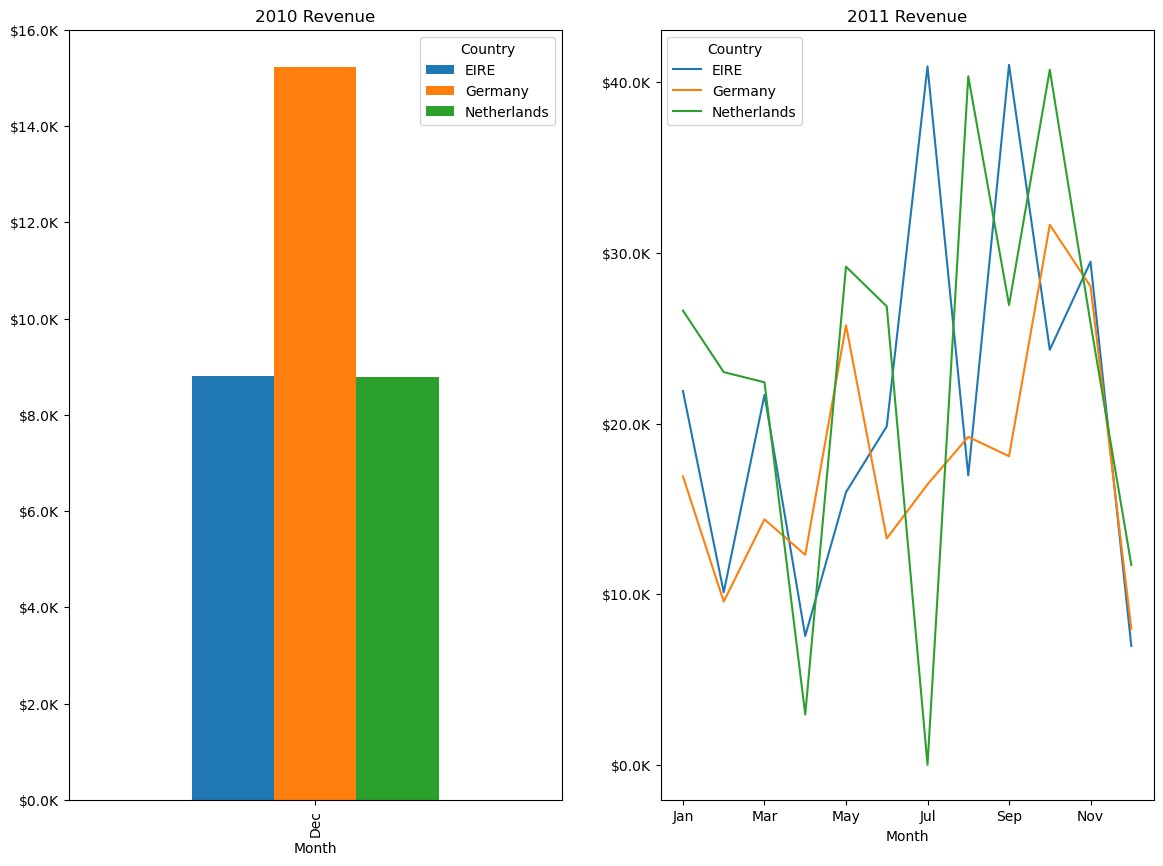

In [6]:
df_top3 = df[df['Country'].isin(tp_3.index)]

#New dataFrame for each Year
df_top3_2010 = df_top3[df_top3.Year == 2010]
df_top3_2011 = df_top3[df_top3.Year == 2011]

#Grouping
grouped_2010 = df_top3_2010.groupby(['Country','Month'])['Revenue'].sum()
grouped_2011 = df_top3_2011.groupby(['Country','Month'])['Revenue'].sum()

#Pivot tables
grouped_2010 = df_top3_2010.pivot_table(
    index='Month',     
    columns='Country', 
    values='Revenue', 
    aggfunc='sum'      
)

grouped_2011 = df_top3_2011.pivot_table(
    index='Month', 
    columns='Country', 
    values='Revenue', 
    aggfunc='sum'
)
calendar = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
grouped_2011 = grouped_2011.reindex(calendar)


#Plotting
fig, ax = plt.subplots(1,2,figsize=(14,10))

grouped_2010.plot(kind='bar', ax=ax[0], title='2010 Revenue')
grouped_2011.plot(kind='line', ax=ax[1], title='2011 Revenue')

ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:F'${str(y/1000)}K'))
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:F'${str(y/1000)}K'))


plt.show()








In [7]:
#Which months are the best and which are the worst(in 2011)
df_2011 = df[df.Year == 2011]
grouped_2011 = df_2011.groupby('Month')['Revenue'].sum()
calendar = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
grouped_2011 = grouped_2011.reindex(calendar).reset_index()
grouped_2011



,Month,Revenue
0,Jan,569445.040
1,Feb,447137.350
2,Mar,595500.760
3,Apr,469200.361
4,May,678594.560
5,Jun,661213.690
6,Jul,600091.011
7,Aug,645343.900
8,Sep,952838.382
9,Oct,1039318.790


In [8]:
AMP = grouped_2011.Revenue.mean()
print(f'Average monthly profit is {AMP}')

Average monthly profit is 694891.1678333334


In [9]:
def Sd(monthly_income):
    solution = ((monthly_income - AMP) / AMP) * 100
    
    return round(solution, 2)

In [10]:
grouped_2011['Sd'] = grouped_2011.Revenue.apply(Sd)
grouped_2011


,Month,Revenue,Sd
0,Jan,569445.040,-18.05
1,Feb,447137.350,-35.65
2,Mar,595500.760,-14.30
3,Apr,469200.361,-32.48
4,May,678594.560,-2.35
5,Jun,661213.690,-4.85
6,Jul,600091.011,-13.64
7,Aug,645343.900,-7.13
8,Sep,952838.382,37.12
9,Oct,1039318.790,49.57


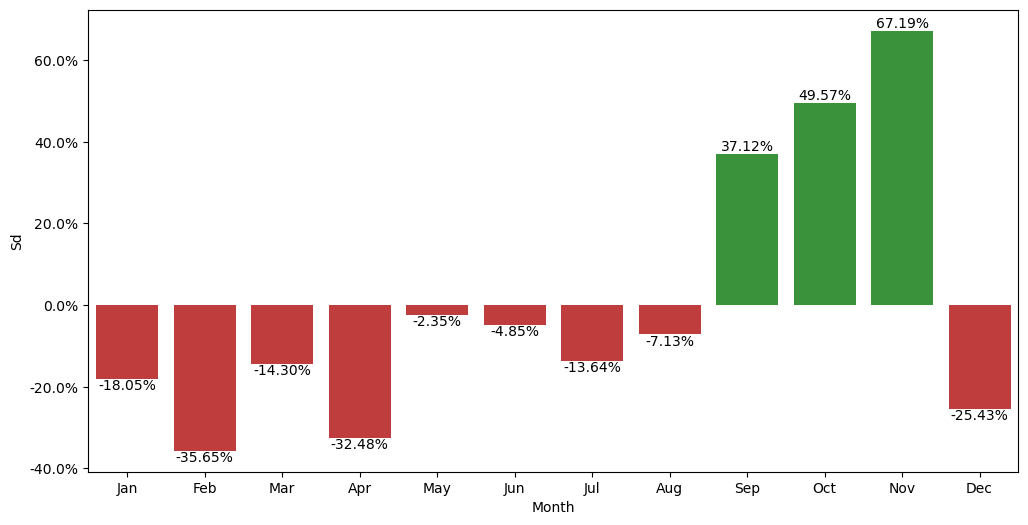

In [11]:
#plot
plt.figure(figsize=(12, 6))
colors = ['#2ca02c' if val > 0 else '#d62728' for val in grouped_2011['Sd']]

ax = sns.barplot(
    data=grouped_2011, 
    x='Month', 
    y='Sd', 
    palette=colors,
    hue='Month',   
    legend=False   
)
for p in ax.containers:
    ax.bar_label(p, fmt='%.2f%%')

plt.savefig('Deviation from mean.png', dpi=300, bbox_inches='tight')
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos:F'{str(y)}%'))